In [19]:
import json
import io
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

pd.set_option("display.max_columns", None)
plt.rcParams["figure.figsize"] = (7, 4)
plt.rcParams["axes.grid"] = True

#EXTRACCIÓN DE DATOS

In [20]:
RAW_URL = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json"

def read_json_from_github(url=RAW_URL):
    r = requests.get(url, timeout=60)
    r.raise_for_status()
    return r.json()

raw = read_json_from_github()
assert isinstance(raw, list), "El JSON no es una lista de objetos."

df_raw = pd.json_normalize(raw, sep=".")
print("Shape original aplanado:", df_raw.shape)
display(df_raw.head())

Shape original aplanado: (7267, 21)


,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,internet.OnlineSecurity,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,No,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,No,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


#TRANSFORMACIÓN DE DATOS

## CONOCER CONJUNTO DE DATOS

In [21]:
print("\n--- Columnas y tipos ---")
display(df_raw.dtypes.to_frame("dtype").head(30))


--- Columnas y tipos ---


,dtype
customerID,object
Churn,object
customer.gender,object
customer.SeniorCitizen,int64
customer.Partner,object
customer.Dependents,object
customer.tenure,int64
phone.PhoneService,object
phone.MultipleLines,object
internet.InternetService,object


## VERIFICAR INCONSISTENCIAS

In [22]:
dup_by_id = df_raw.duplicated(subset=["customerID"]).sum() if "customerID" in df_raw.columns else None
null_counts = df_raw.isna().sum().sort_values(ascending=False)
empty_string_counts = (df_raw.applymap(lambda x: isinstance(x, str) and x.strip() == "")
                       .sum()
                       .sort_values(ascending=False))

print(f"\nDuplicados por customerID: {dup_by_id}")
print("\nTop 10 nulos por columna:")
display(null_counts.head(10).to_frame("n_nulos"))
print("\nTop 10 cadenas vacías por columna:")
display(empty_string_counts.head(10).to_frame("n_vacios"))


Duplicados por customerID: 0

Top 10 nulos por columna:


/tmp/ipython-input-188389974.py:3: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  empty_string_counts = (df_raw.applymap(lambda x: isinstance(x, str) and x.strip() == "")


,n_nulos
customerID,0
Churn,0
customer.gender,0
customer.SeniorCitizen,0
customer.Partner,0
customer.Dependents,0
customer.tenure,0
phone.PhoneService,0
phone.MultipleLines,0
internet.InternetService,0



Top 10 cadenas vacías por columna:


,n_vacios
Churn,224
account.Charges.Total,11
customerID,0
customer.SeniorCitizen,0
customer.gender,0
customer.Partner,0
customer.Dependents,0
phone.PhoneService,0
customer.tenure,0
internet.InternetService,0


## TRANSFORMACIONES Y LIMPIEZA

In [23]:
df = df_raw.copy()

# Renombrar columnas a nombres amigables
rename_map = {
    "customer.gender": "gender",
    "customer.SeniorCitizen": "SeniorCitizen",
    "customer.Partner": "Partner",
    "customer.Dependents": "Dependents",
    "customer.tenure": "tenure",
    "phone.PhoneService": "PhoneService",
    "phone.MultipleLines": "MultipleLines",
    "internet.InternetService": "InternetService",
    "internet.OnlineSecurity": "OnlineSecurity",
    "internet.OnlineBackup": "OnlineBackup",
    "internet.DeviceProtection": "DeviceProtection",
    "internet.TechSupport": "TechSupport",
    "internet.StreamingTV": "StreamingTV",
    "internet.StreamingMovies": "StreamingMovies",
    "account.Contract": "Contract",
    "account.PaperlessBilling": "PaperlessBilling",
    "account.PaymentMethod": "PaymentMethod",
    "account.Charges.Monthly": "MonthlyCharges",
    "account.Charges.Total": "TotalCharges",
}
df.rename(columns=rename_map, inplace=True)

In [24]:

# TotalCharges a numérico
if "TotalCharges" in df.columns:
    df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Estandarizar "No internet service" / "No phone service" => "No"
for col in ["OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies"]:
    if col in df.columns:
        df[col] = df[col].replace({"No internet service": "No"})
if "MultipleLines" in df.columns:
    df["MultipleLines"] = df["MultipleLines"].replace({"No phone service": "No"})

# Tratar Churn vacío como NaN y filtrar esas filas
if "Churn" in df.columns:
    df["Churn"] = df["Churn"].replace({"": np.nan})
    churn_missing = int(df["Churn"].isna().sum())
else:
    churn_missing = None

df = df.dropna(subset=["Churn"]).copy()

# Asegurar tipos numéricos claves
for c in ["MonthlyCharges", "tenure"]:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

# Crear columna Cuentas_Diarias = MonthlyCharges/30
if "MonthlyCharges" in df.columns:
    df["Cuentas_Diarias"] = df["MonthlyCharges"] / 30.0

# Estandarización binaria (opcional pero recomendada)
binary_map = {"Yes": 1, "No": 0, "Female": 0, "Male": 1}
for col in ["Partner","Dependents","PaperlessBilling","PhoneService","MultipleLines",
            "OnlineSecurity","OnlineBackup","DeviceProtection","TechSupport",
            "StreamingTV","StreamingMovies","gender"]:
    if col in df.columns:
        df[col + "_bin"] = df[col].map(binary_map)

# Variable binaria de churn
df["Churn_bin"] = df["Churn"].map({"Yes": 1, "No": 0})

print("\nShape dataset limpio:", df.shape)
display(df.head())


Shape dataset limpio: (7043, 35)


,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Cuentas_Diarias,Partner_bin,Dependents_bin,PaperlessBilling_bin,PhoneService_bin,MultipleLines_bin,OnlineSecurity_bin,OnlineBackup_bin,DeviceProtection_bin,TechSupport_bin,StreamingTV_bin,StreamingMovies_bin,gender_bin,Churn_bin
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30,2.186667,1,1,1,1,0,0,1,0,1,1,0,0,0
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,No,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40,1.996667,0,0,0,1,1,0,0,0,0,0,1,1,0
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,2.463333,0,0,1,1,0,0,0,1,0,0,0,1,1
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,3.266667,1,0,1,1,0,0,1,1,0,1,1,1,1
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,No,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40,2.796667,1,0,1,1,0,0,0,0,1,1,0,0,1


## ANÁLISIS DESCRIPTIVO

In [25]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
desc = df[numeric_cols].describe().T
print("\n--- Estadísticos descriptivos (numéricas) ---")
display(desc[["mean", "std", "min", "25%", "50%", "75%", "max"]].round(3))

# Mediana (por si la quieres explícita)
medianas = df[numeric_cols].median(numeric_only=True).round(3)
print("\nMedianas:")
display(medianas.to_frame("median"))


--- Estadísticos descriptivos (numéricas) ---


,mean,std,min,25%,50%,75%,max
SeniorCitizen,0.162,0.369,0.000,0.000,0.000,0.000,1.000
tenure,32.371,24.559,0.000,9.000,29.000,55.000,72.000
MonthlyCharges,64.762,30.090,18.250,35.500,70.350,89.850,118.750
TotalCharges,2283.300,2266.771,18.800,401.450,1397.475,3794.738,8684.800
Cuentas_Diarias,2.159,1.003,0.608,1.183,2.345,2.995,3.958
Partner_bin,0.483,0.500,0.000,0.000,0.000,1.000,1.000
Dependents_bin,0.300,0.458,0.000,0.000,0.000,1.000,1.000
PaperlessBilling_bin,0.592,0.491,0.000,0.000,1.000,1.000,1.000
PhoneService_bin,0.903,0.296,0.000,1.000,1.000,1.000,1.000
MultipleLines_bin,0.422,0.494,0.000,0.000,0.000,1.000,1.000



Medianas:


,median
SeniorCitizen,0.000
tenure,29.000
MonthlyCharges,70.350
TotalCharges,1397.475
Cuentas_Diarias,2.345
Partner_bin,0.000
Dependents_bin,0.000
PaperlessBilling_bin,1.000
PhoneService_bin,1.000
MultipleLines_bin,0.000


## DISTRIBUCIÓN DE CHURN

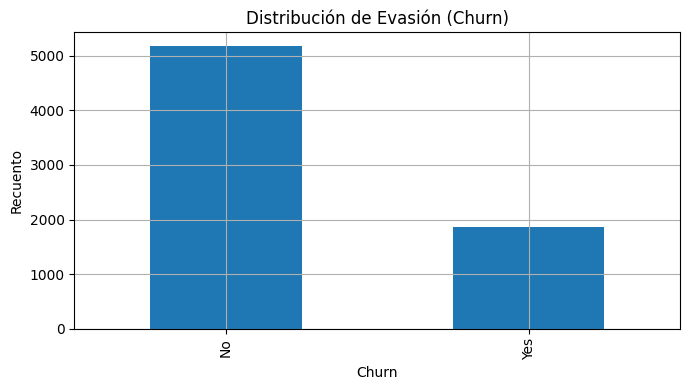

Tasa global de churn: 26.54%


In [26]:
churn_counts = df["Churn"].value_counts()
churn_rate = df["Churn_bin"].mean()

plt.figure()
churn_counts.plot(kind="bar")
plt.title("Distribución de Evasión (Churn)")
plt.xlabel("Churn")
plt.ylabel("Recuento")
plt.tight_layout()
plt.show()

print(f"Tasa global de churn: {churn_rate:.2%}")

## CHURN POR VARIABLES CATEGÓRICAS

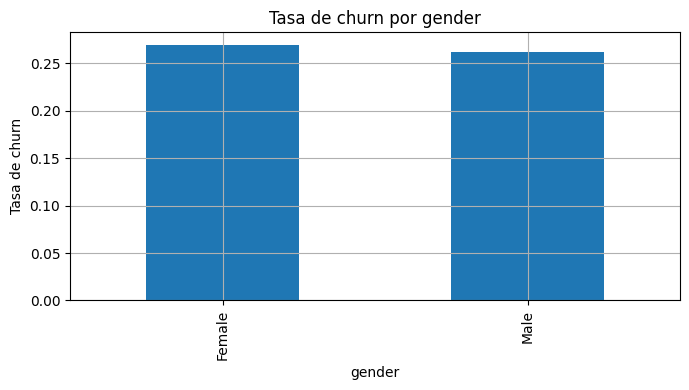

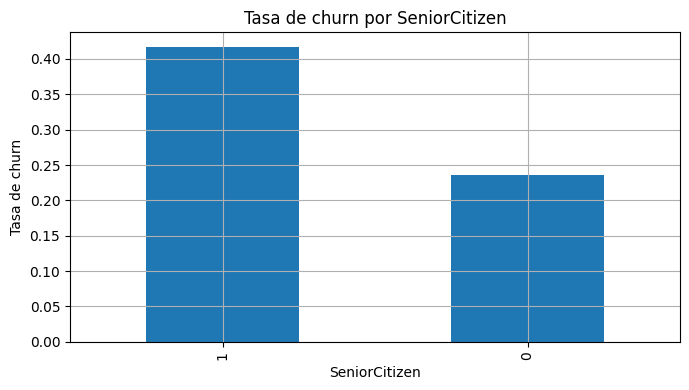

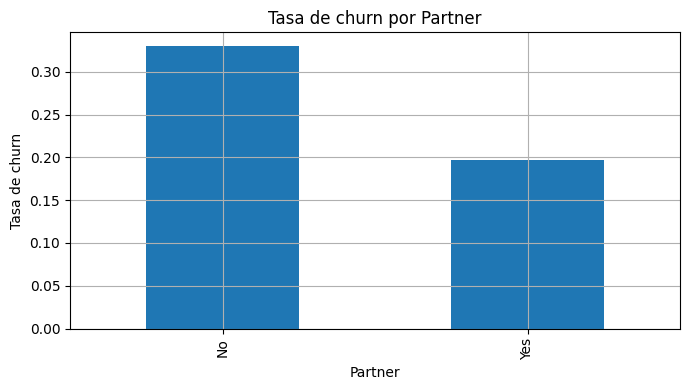

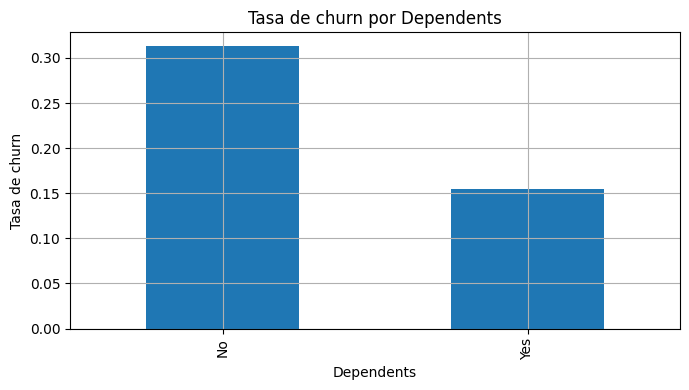

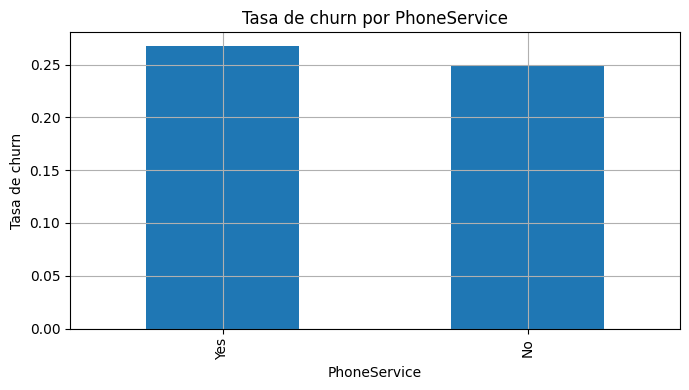

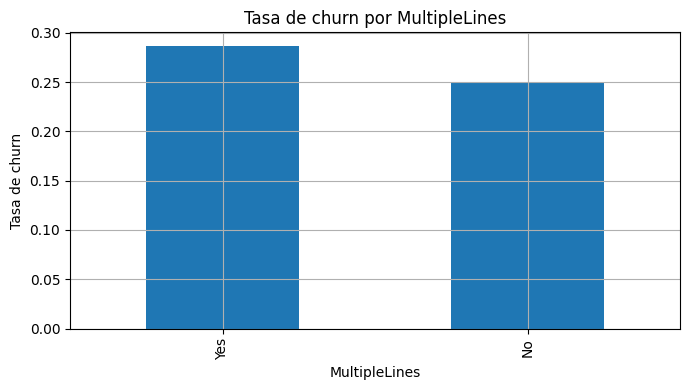

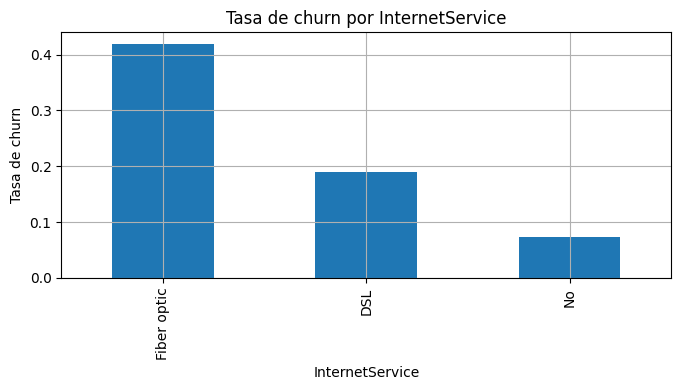

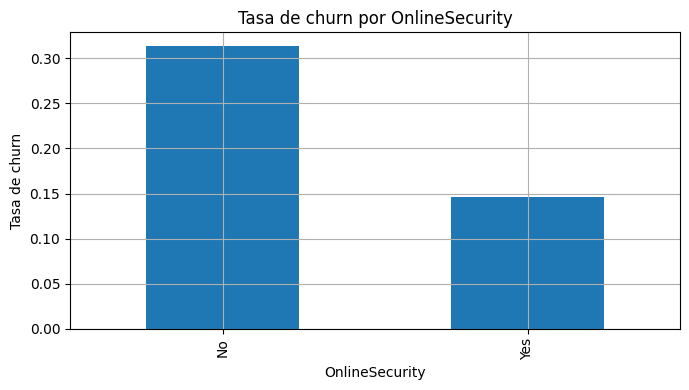

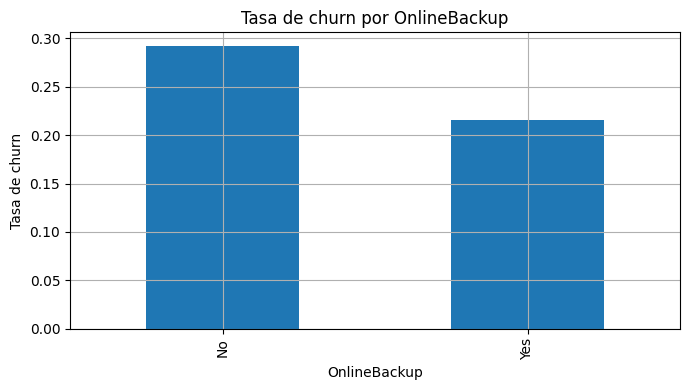

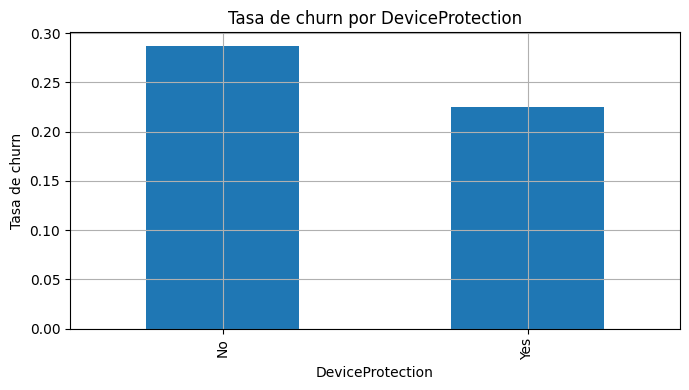

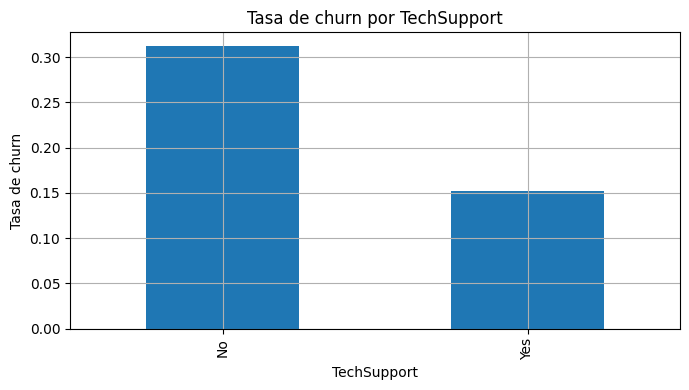

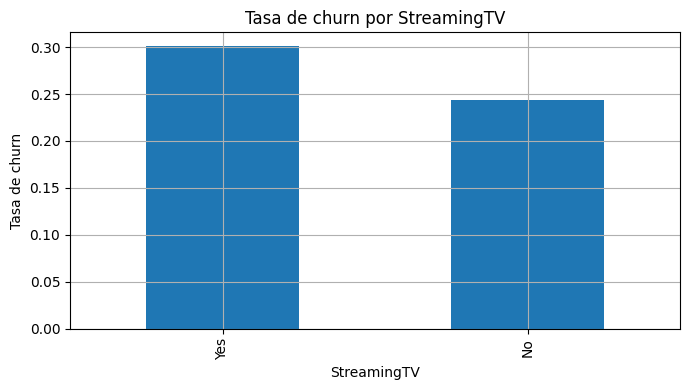

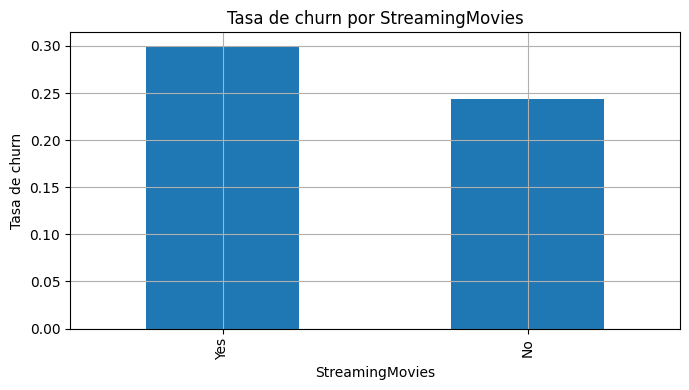

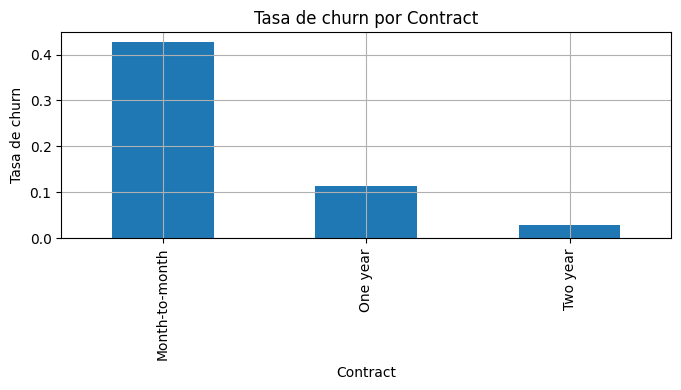

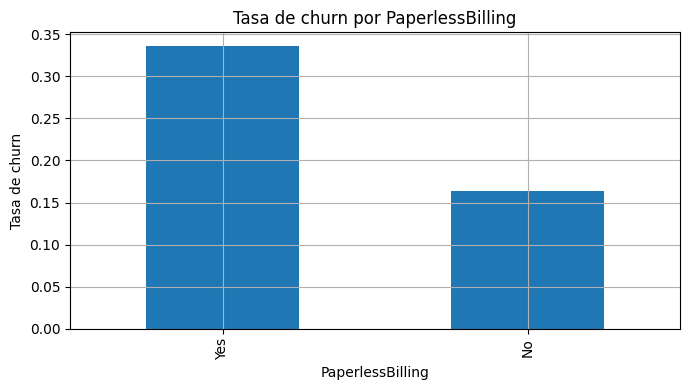

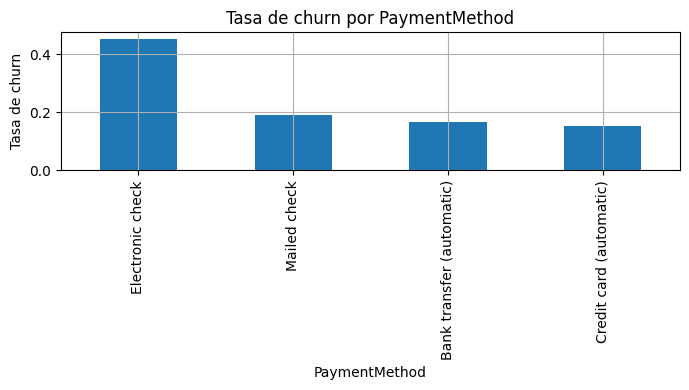

In [27]:
categorical_cols = [
    "gender", "SeniorCitizen", "Partner", "Dependents", "PhoneService", "MultipleLines",
    "InternetService", "OnlineSecurity", "OnlineBackup", "DeviceProtection",
    "TechSupport", "StreamingTV", "StreamingMovies",
    "Contract", "PaperlessBilling", "PaymentMethod"
]

def churn_rate_by_category(df, col):
    t = (
        df.groupby(col)["Churn_bin"]
        .agg(["mean", "count"])
        .rename(columns={"mean": "churn_rate", "count": "n"})
        .sort_values("churn_rate", ascending=False)
    )
    return t

churn_by_cat = {}
for col in categorical_cols:
    if col in df.columns:
        t = churn_rate_by_category(df, col)
        churn_by_cat[col] = t

        # Grafico de barras de tasa de churn por categoría
        plt.figure()
        t["churn_rate"].plot(kind="bar")
        plt.title(f"Tasa de churn por {col}")
        plt.ylabel("Tasa de churn")
        plt.tight_layout()
        plt.show()


## CHURN POR VARIABLES NUMÉRICAS

/tmp/ipython-input-2500194048.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([data_no, data_yes], labels=["No", "Yes"])


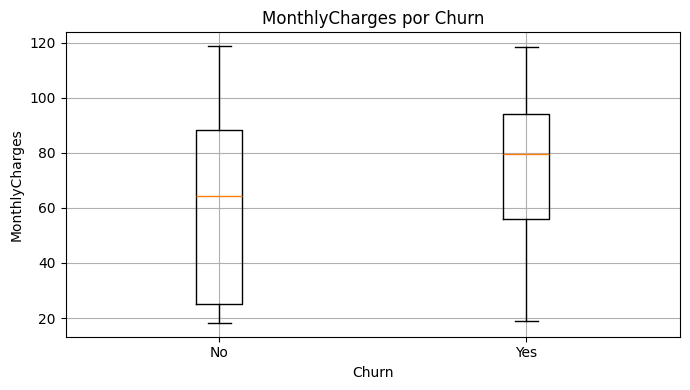

/tmp/ipython-input-2500194048.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([data_no, data_yes], labels=["No", "Yes"])


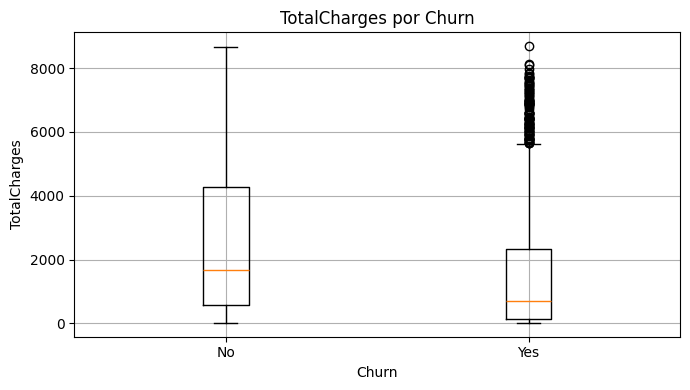

/tmp/ipython-input-2500194048.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([data_no, data_yes], labels=["No", "Yes"])


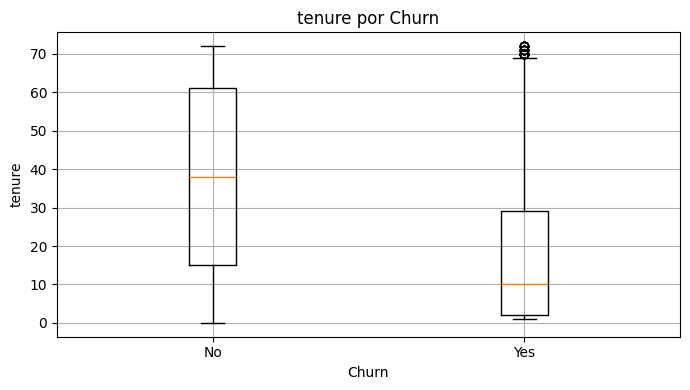

/tmp/ipython-input-2500194048.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([data_no, data_yes], labels=["No", "Yes"])


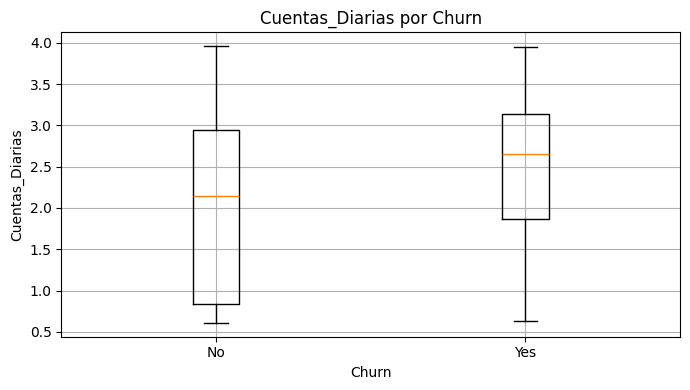

In [28]:
num_to_plot = [c for c in ["MonthlyCharges", "TotalCharges", "tenure", "Cuentas_Diarias"] if c in df.columns]

for c in num_to_plot:
    plt.figure()
    # Boxplot por churn usando matplotlib puro
    # Preparamos datos:
    data_yes = df.loc[df["Churn"] == "Yes", c].dropna()
    data_no  = df.loc[df["Churn"] == "No", c].dropna()
    plt.boxplot([data_no, data_yes], labels=["No", "Yes"])
    plt.title(f"{c} por Churn")
    plt.xlabel("Churn")
    plt.ylabel(c)
    plt.tight_layout()
    plt.show()

INSIGHTS Y RECOMENDACIONES

In [29]:
insights = []

if "Contract" in churn_by_cat and len(churn_by_cat["Contract"]) > 0:
    top_contract = churn_by_cat["Contract"].reset_index().sort_values("churn_rate", ascending=False)
    insights.append(
        f"- Contrato con mayor churn: **{top_contract.iloc[0]['Contract']}** "
        f"(tasa={top_contract.iloc[0]['churn_rate']:.2%}, n={int(top_contract.iloc[0]['n'])})."
    )

if "InternetService" in churn_by_cat and len(churn_by_cat["InternetService"]) > 0:
    top_internet = churn_by_cat["InternetService"].reset_index().sort_values("churn_rate", ascending=False)
    insights.append(
        f"- Tipo de internet con mayor churn: **{top_internet.iloc[0]['InternetService']}** "
        f"(tasa={top_internet.iloc[0]['churn_rate']:.2%}, n={int(top_internet.iloc[0]['n'])})."
    )

if "TechSupport" in churn_by_cat and all(k in churn_by_cat["TechSupport"].index for k in ["No", "Yes"]):
    insights.append(
        f"- Soporte técnico muestra brecha: **No**={churn_by_cat['TechSupport'].loc['No','churn_rate']:.2%} "
        f"vs **Yes**={churn_by_cat['TechSupport'].loc['Yes','churn_rate']:.2%}."
    )

if "PaperlessBilling" in churn_by_cat and all(k in churn_by_cat["PaperlessBilling"].index for k in ["No", "Yes"]):
    insights.append(
        f"- PaperlessBilling: **Yes**={churn_by_cat['PaperlessBilling'].loc['Yes','churn_rate']:.2%} "
        f"vs **No**={churn_by_cat['PaperlessBilling'].loc['No','churn_rate']:.2%}."
    )

report_md = f"""
# Telecom X – Análisis de Evasión de Clientes

## 1. Introducción
La empresa enfrenta una alta tasa de cancelaciones. Este análisis **ETL + EDA** busca identificar patrones
y factores asociados al **churn** para apoyar estrategias de retención y futuros modelos predictivos.

## 2. Limpieza y Tratamiento de Datos
- Fuente: JSON público del challenge (GitHub).
- Normalización con `pandas.json_normalize`.
- Conversión de `TotalCharges` a numérico.
- Estandarización de categorías: `"No internet service"/"No phone service"` → `"No"`.
- Filtrado de filas sin `Churn` (removidas: **{churn_missing}**).
- Creación de `Cuentas_Diarias = MonthlyCharges / 30`.
- Columnas binarias auxiliares (`*_bin`) y `Churn_bin`.

Duplicados por `customerID`: **{dup_by_id}**  
Registros finales: **{len(df)}**.

## 3. Análisis Exploratorio de Datos (resumen)
- Tasa global de churn: **{churn_rate:.2%}**
- Variables numéricas (resumen):
{desc[["mean","std","min","25%","50%","75%","max"]].round(2).to_markdown()}

## 4. Hallazgos / Insights
{chr(10).join(insights) if insights else "- (Se requieren análisis adicionales por segmento)"}

## 5. Recomendaciones
1. Incentivar **contratos de mayor plazo** en segmentos con churn elevado.
2. Fortalecer/educar en **TechSupport** y **OnlineSecurity** para clientes de internet con mayor propensión.
3. Auditar la experiencia de **PaperlessBilling** si su tasa es mayor.
4. Priorizar retención en segmentos con **MonthlyCharges**/`Cuentas_Diarias` y **tenure** críticos (identificados en boxplots).
5. Preparar dataset para modelado (train/test), con `tenure`, cargos, servicios y variables binarias como features.

*Nota:* Este informe se genera automáticamente dentro del notebook.
"""
display(Markdown(report_md))
